# ML Project - Logistic Regression Titanic Survival

# Part-1: Data Exploration and Pre-processing

# 1) load the given dataset

In [1]:
import pandas as pd 

In [2]:
data = pd.read_csv(r"C:\Users\nisth\Downloads\ML PROJECTS\ML PROJECT CSV DATASET\ML Project - Logistic Regression Titanic Survival U16955478860.csv")

In [3]:
data

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# 2) print all the column names

In [4]:
data.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

# 3) describe the data

In [5]:
data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 4) check the null value

In [6]:
data.isnull().any()

Survived    False
Pclass      False
Name        False
Sex         False
Age          True
SibSp       False
Parch       False
Ticket      False
Fare        False
Cabin        True
Embarked     True
dtype: bool

In [7]:
data.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [9]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 5) if there are Null values, Handle these

In [10]:
import warnings 
warnings.filterwarnings('ignore')

In [11]:
#Age is numerical, so we can replace missing values with the median.
#Why median?
#Because age can have some extreme values, and median is generally safer than mean in such cases.

data['Age'].fillna(data['Age'].median(), inplace=True)

In [12]:
data.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [13]:
#Embarked
#Embarked is categorical (S, C, Q), so use the mode.

data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

In [14]:
data.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      0
dtype: int64

In [15]:
#Cabin
#Your Cabin column has 687 missing values out of 891, which is a very large percentage.
#For this project, the simplest approach is to drop the Cabin column.

data.drop('Cabin', axis=1, inplace=True)

In [16]:
data.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

# Part-2: Working with Models

# 1) Create the target data and feature data where target data is survived

In [17]:
x = data.drop('Survived' , axis = 1)
y = data['Survived']

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 69.7+ KB


In [19]:
x = x.drop(['Name', 'Ticket'], axis=1)

In [20]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [21]:
from sklearn.preprocessing import LabelEncoder

In [22]:
enc =LabelEncoder()

In [23]:
x['Sex'] = enc.fit_transform(x['Sex'])

In [24]:
x['Embarked'] = enc.fit_transform(x['Embarked'])

In [25]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,0
2,3,0,26.0,0,0,7.9250,2
3,1,0,35.0,1,0,53.1000,2
4,3,1,35.0,0,0,8.0500,2


In [26]:
x.dtypes

Pclass        int64
Sex           int32
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int32
dtype: object

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 69.7+ KB


# 2) Split the data into Training and testing Set

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)

# 3) Create a Logistic regression model for Target and feature data

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
model = LogisticRegression()

In [32]:
model.fit(x_train, y_train)

LogisticRegression()

In [51]:
model.score(x_train , y_train)

0.800561797752809

In [52]:
model.score(x_test , y_test)

0.8100558659217877

In [33]:
y_pred = model.predict(x_test)

In [34]:
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1], dtype=int64)

In [35]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

# 4) Find the Accuracy Score

In [36]:
accuracy_score(y_test , y_pred)

0.8100558659217877

# 5) Display the Confusion Matrix

In [37]:
confusion_matrix(y_test , y_pred)

array([[90, 15],
       [19, 55]], dtype=int64)

In [38]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



# 6) Find the Precision Score

In [39]:
from sklearn.metrics import precision_score

In [40]:
precision_score(y_test, y_pred)

0.7857142857142857

# 7) Find the Recall Score

In [41]:
from sklearn.metrics import recall_score

recall_score(y_test, y_pred)

0.7432432432432432

# 8) Find the F1 Score

In [42]:
from sklearn.metrics import f1_score

f1_score(y_test, y_pred)

0.7638888888888888

# 9) Find the probability of testing data



In [43]:
y_prob = model.predict_proba(x_test)

In [44]:
print(y_prob)

[[0.88611526 0.11388474]
 [0.77835477 0.22164523]
 [0.86512726 0.13487274]
 [0.11436733 0.88563267]
 [0.25481345 0.74518655]
 [0.06933517 0.93066483]
 [0.32886592 0.67113408]
 [0.90880181 0.09119819]
 [0.25378687 0.74621313]
 [0.07921484 0.92078516]
 [0.66685023 0.33314977]
 [0.9301258  0.0698742 ]
 [0.61162063 0.38837937]
 [0.84904054 0.15095946]
 [0.8024907  0.1975093 ]
 [0.06359854 0.93640146]
 [0.7000471  0.2999529 ]
 [0.32882162 0.67117838]
 [0.75547634 0.24452366]
 [0.66977919 0.33022081]
 [0.87871862 0.12128138]
 [0.59292022 0.40707978]
 [0.38348124 0.61651876]
 [0.86474239 0.13525761]
 [0.88947088 0.11052912]
 [0.93143939 0.06856061]
 [0.52949767 0.47050233]
 [0.77725986 0.22274014]
 [0.91881946 0.08118054]
 [0.40047023 0.59952977]
 [0.86154546 0.13845454]
 [0.33689985 0.66310015]
 [0.43668941 0.56331059]
 [0.37894356 0.62105644]
 [0.8578275  0.1421725 ]
 [0.87117431 0.12882569]
 [0.54258929 0.45741071]
 [0.32886592 0.67113408]
 [0.05778476 0.94221524]
 [0.89110557 0.10889443]


In [45]:
y_prob_survived = model.predict_proba(x_test)[:, 1]

In [46]:
print(y_prob_survived)

[0.11388474 0.22164523 0.13487274 0.88563267 0.74518655 0.93066483
 0.67113408 0.09119819 0.74621313 0.92078516 0.33314977 0.0698742
 0.38837937 0.15095946 0.1975093  0.93640146 0.2999529  0.67117838
 0.24452366 0.33022081 0.12128138 0.40707978 0.61651876 0.13525761
 0.11052912 0.06856061 0.47050233 0.22274014 0.08118054 0.59952977
 0.13845454 0.66310015 0.56331059 0.62105644 0.1421725  0.12882569
 0.45741071 0.67113408 0.94221524 0.10889443 0.20102005 0.08101936
 0.10893236 0.13196719 0.57929289 0.0911857  0.13853391 0.12493004
 0.12105313 0.33786636 0.72343396 0.80799808 0.0407812  0.51077892
 0.04698948 0.93205777 0.21643945 0.93211855 0.77656625 0.72860263
 0.13131766 0.85810553 0.76450954 0.45139504 0.13196719 0.63404955
 0.3117137  0.10597127 0.14966752 0.87521269 0.75520704 0.94938364
 0.57779104 0.9041345  0.12455077 0.06785864 0.65412838 0.94573862
 0.75661208 0.47671451 0.05003061 0.80246253 0.9124328  0.13196356
 0.35491155 0.26769438 0.93557559 0.94569058 0.36237617 0.10873

# ROC Curve and AUC Score

In [47]:
from sklearn.metrics import roc_curve, roc_auc_score

In [48]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_survived)

In [49]:
auc = roc_auc_score(y_test, y_prob_survived)

print("AUC Score:", auc)

AUC Score: 0.8823680823680824


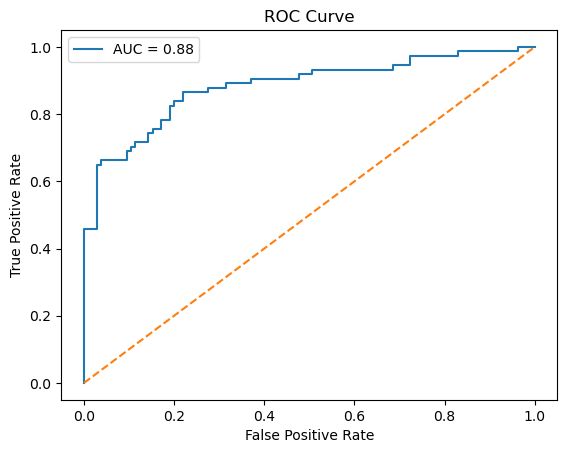

In [50]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label='AUC = {:.2f}'.format(auc))

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()